In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 베이스 파일 로드 (전처리 완료된 주문-아이템 단위 데이터)
df = pd.read_csv('../../../Funnel_Cohort_NG/data/olist_order_item_level.csv')

# 배송 완료된 주문만 필터링
# - 미완료 주문은 실제 배송일이 없어 지연 여부 판단 불가
df = df[df['order_status'] == 'delivered'].copy()

# 날짜 컬럼 datetime 변환
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# 실제 배송일 - 예정일 차이 (음수 = 조기 도착, 양수 = 지연)
df['days_diff'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# 배송 유형별 평균 리뷰 점수
early_review = df[df['days_diff'] < 0]['review_score_mean'].mean()
normal_review = df[df['days_diff'] == 0]['review_score_mean'].mean()
late_review = df[df['is_late'] == True]['review_score_mean'].mean()

print(f"=== 현재 베이스라인 ===")
print(f"분석 대상 주문 수: {len(df):,}건")
print(f"현재 지연율: {df['is_late'].mean()*100:.1f}%")
print(f"현재 평균 리뷰: {df['review_score_mean'].mean():.3f}")
print()
print(f"=== 배송 유형별 평균 리뷰 ===")
print(f"조기 도착: {early_review:.3f}점 ({(df['days_diff'] < 0).sum():,}건)")
print(f"정시 배송: {normal_review:.3f}점 ({(df['days_diff'] == 0).sum():,}건)")
print(f"지연 배송: {late_review:.3f}점 ({df['is_late'].sum():,}건)")

=== 현재 베이스라인 ===
분석 대상 주문 수: 110,197건
현재 지연율: 7.9%
현재 평균 리뷰: 4.082

=== 배송 유형별 평균 리뷰 ===
조기 도착: 4.212점 (101,475건)
정시 배송: 3.987점 (1,450건)
지연 배송: 2.549점 (8,714건)


In [5]:
# A/B 테스트 시뮬레이션
# 가설: 예정일을 X일 늘리면 현재 지연 주문 중 일부가 조기 도착으로 전환됨
# 전환된 주문의 리뷰는 조기 도착 평균(4.212점)으로 개선된다고 가정
# 한계: 예정일 연장 시 구매 포기 고객 증가 효과는 반영 불가

results = []

for extra_days in range(0, 8):
    # 예정일을 extra_days만큼 늘렸을 때 지연 여부 재계산
    new_estimated = df['order_estimated_delivery_date'] + pd.Timedelta(days=extra_days)
    new_is_late = df['order_delivered_customer_date'] > new_estimated
    
    # 지연→정시/조기 전환된 주문 수
    converted = (df['is_late'] == True) & (new_is_late == False)
    converted_count = converted.sum()
    
    # 예상 평균 리뷰
    # 전환된 주문은 조기 도착 평균 리뷰(4.212)로 개선된다고 가정
    total = len(df)
    new_late_count = new_is_late.sum()
    new_normal_count = total - new_late_count
    
    expected_review = (
        (early_review * new_normal_count + late_review * new_late_count) / total
    )
    
    results.append({
        '추가일수': extra_days,
        '지연율': round(new_is_late.mean() * 100, 2),
        '전환건수': converted_count,
        '예상평균리뷰': round(expected_review, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string())

   추가일수   지연율  전환건수  예상평균리뷰
0     0  7.91     0   4.080
1     1  6.59  1450   4.102
2     2  5.74  2388   4.116
3     3  5.19  2991   4.125
4     4  4.68  3560   4.134
5     5  4.23  4055   4.141
6     6  3.77  4562   4.149
7     7  3.36  5014   4.156


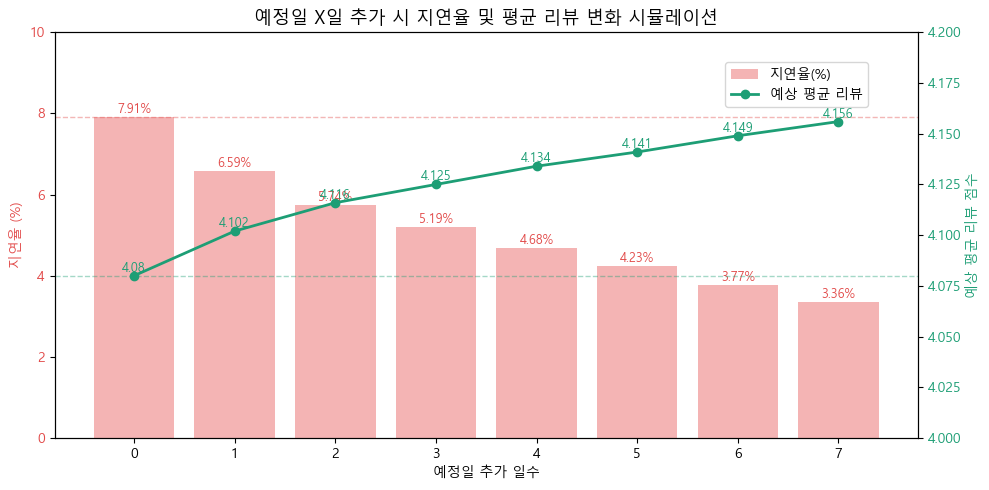

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x = results_df['추가일수']

# 지연율 막대
ax1.bar(x, results_df['지연율'], color='#F09595', alpha=0.7, label='지연율(%)')
ax1.set_xlabel('예정일 추가 일수')
ax1.set_ylabel('지연율 (%)', color='#E24B4A')
ax1.tick_params(axis='y', labelcolor='#E24B4A')
ax1.set_ylim(0, 10)

for i, row in results_df.iterrows():
    ax1.text(row['추가일수'], row['지연율'] + 0.1,
             f"{row['지연율']}%", ha='center', fontsize=9, color='#E24B4A')

# 평균 리뷰 꺾은선
ax2 = ax1.twinx()
ax2.plot(x, results_df['예상평균리뷰'], color='#1D9E75', marker='o', linewidth=2, label='예상 평균 리뷰')
ax2.set_ylabel('예상 평균 리뷰 점수', color='#1D9E75')
ax2.tick_params(axis='y', labelcolor='#1D9E75')
ax2.set_ylim(4.0, 4.2)

for i, row in results_df.iterrows():
    ax2.text(row['추가일수'], row['예상평균리뷰'] + 0.002,
             f"{row['예상평균리뷰']}", ha='center', fontsize=9, color='#1D9E75')

# 베이스라인 표시
ax1.axhline(y=7.91, color='#E24B4A', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(y=4.080, color='#1D9E75', linestyle='--', alpha=0.4, linewidth=1)

plt.title('예정일 X일 추가 시 지연율 및 평균 리뷰 변화 시뮬레이션', fontsize=13)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('ab_test_eta_simulation.png', dpi=150, bbox_inches='tight')
plt.show()